In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "spectral_code").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from spectral_code.utils.dataset_paths import OUTPUTS_ROOT

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 160)

OUTPUT_ROOT = OUTPUTS_ROOT / "bcb" / "type123_type4_balanced_threshold"
REPORTS_DIR = OUTPUT_ROOT / "reports"
SUMMARY_JSON = REPORTS_DIR / "balanced_type123_type4_threshold_summary.json"
RESULTS_CSV = REPORTS_DIR / "balanced_type123_type4_threshold_results.csv"
SCORES_CSV = REPORTS_DIR / "balanced_type123_type4_pair_scores.csv"

for p in [SUMMARY_JSON, RESULTS_CSV, SCORES_CSV]:
    print(p.name, p.exists(), p)


balanced_type123_type4_threshold_summary.json True C:\Users\koush\PyProjects\spectrals\outputs\bcb\type123_type4_balanced_threshold\reports\balanced_type123_type4_threshold_summary.json
balanced_type123_type4_threshold_results.csv True C:\Users\koush\PyProjects\spectrals\outputs\bcb\type123_type4_balanced_threshold\reports\balanced_type123_type4_threshold_results.csv
balanced_type123_type4_pair_scores.csv True C:\Users\koush\PyProjects\spectrals\outputs\bcb\type123_type4_balanced_threshold\reports\balanced_type123_type4_pair_scores.csv


## Load Outputs

In [2]:
if not SUMMARY_JSON.exists() or not RESULTS_CSV.exists():
    print("Run this first:")
    print("python notebooks/datasets/bigclonebench/run_pipeline/00_train_balanced_type123_type4_threshold.py")
    raise FileNotFoundError("Balanced threshold outputs are missing.")

summary = json.loads(SUMMARY_JSON.read_text(encoding="utf-8"))
results_df = pd.read_csv(RESULTS_CSV)
scores_df = pd.read_csv(SCORES_CSV) if SCORES_CSV.exists() else pd.DataFrame()

selection = summary.get("selection", {})
display(pd.DataFrame([
    {"item": "graph types", "value": ", ".join(map(str, summary.get("graph_types", [])))},
    {"item": "metrics", "value": ", ".join(map(str, summary.get("metrics", [])))},
    {"item": "eigen threshold", "value": summary.get("eigen_threshold")},
    {"item": "graph filter mode", "value": summary.get("graph_filter_mode")},
    {"item": "type4 ratio", "value": summary.get("type4_ratio")},
    {"item": "type123 after filter", "value": selection.get("type123_positive_after_filter")},
    {"item": "type4 sampled", "value": selection.get("type4_positive_sampled")},
    {"item": "non-clone sampled", "value": selection.get("non_clone_sampled")},
    {"item": "total selected pairs", "value": selection.get("selected_total_pairs")},
]))

display(results_df.sort_values(["accuracy", "f1", "auc"], ascending=False))


,item,value
0,graph types,"ast, cpg"
1,metrics,pss
2,eigen threshold,50
3,graph filter mode,all_graphs
4,type4 ratio,0.25
5,type123 after filter,96571
6,type4 sampled,24143
7,non-clone sampled,75746
8,total selected pairs,196460


,optimized_for,graph_type,metric,metric_parameters,k_eigen,best_threshold,decision_threshold,best_metric,pairs,positive_pairs,negative_pairs,accuracy,precision,recall,f1,auc,config_seconds
0,f1,ast,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",full,0.640288,0.640288,0.782345,196460,120714,75746,0.693917,0.694715,0.895273,0.782345,0.812340,11.593462
1,f1,cpg,pss,"{'pss_gamma': 0.1, 'pss_distance_power': 1.0}",full,0.552388,0.552388,0.770906,196460,120714,75746,0.652005,0.647283,0.952897,0.770906,0.782775,11.611406


## Metric Text Summary

In [3]:
if results_df.empty:
    print("No result rows found.")
else:
    best = results_df.sort_values(["accuracy", "f1", "auc"], ascending=False).iloc[0]
    print(
        f"Best config: {best['graph_type'].upper()} / {best['metric']} / k={best['k_eigen']} "
        f"threshold={best['best_threshold']:.6f}"
    )
    print(
        f"Accuracy={best['accuracy']:.4f}, Precision={best['precision']:.4f}, "
        f"Recall={best['recall']:.4f}, F1={best['f1']:.4f}, AUC={best['auc']:.4f}"
    )
    for row in results_df.sort_values(["graph_type", "metric", "k_eigen"]).itertuples(index=False):
        print(
            f"{str(row.graph_type).upper()} {row.metric} k={row.k_eigen}: "
            f"acc={row.accuracy:.4f}, prec={row.precision:.4f}, rec={row.recall:.4f}, "
            f"f1={row.f1:.4f}, auc={row.auc:.4f}, th={row.best_threshold:.6f}, "
            f"pairs={int(row.pairs):,}"
        )


Best config: AST / pss / k=full threshold=0.640288
Accuracy=0.6939, Precision=0.6947, Recall=0.8953, F1=0.7823, AUC=0.8123
AST pss k=full: acc=0.6939, prec=0.6947, rec=0.8953, f1=0.7823, auc=0.8123, th=0.640288, pairs=196,460
CPG pss k=full: acc=0.6520, prec=0.6473, rec=0.9529, f1=0.7709, auc=0.7828, th=0.552388, pairs=196,460


## Performance Plots

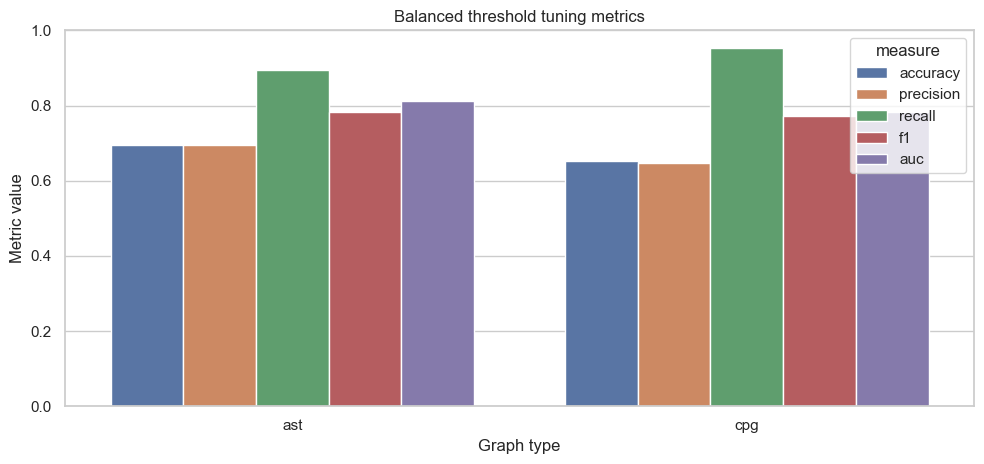

In [4]:
metric_cols = ["accuracy", "precision", "recall", "f1", "auc"]
plot_df = results_df.melt(
    id_vars=["graph_type", "metric", "k_eigen", "best_threshold", "pairs"],
    value_vars=[c for c in metric_cols if c in results_df.columns],
    var_name="measure",
    value_name="value",
)
plt.figure(figsize=(10, 4.8))
sns.barplot(data=plot_df, x="graph_type", y="value", hue="measure")
plt.ylim(0, 1)
plt.xlabel("Graph type")
plt.ylabel("Metric value")
plt.title("Balanced threshold tuning metrics")
plt.tight_layout()
plt.show()


## Score Distributions With Learned Thresholds

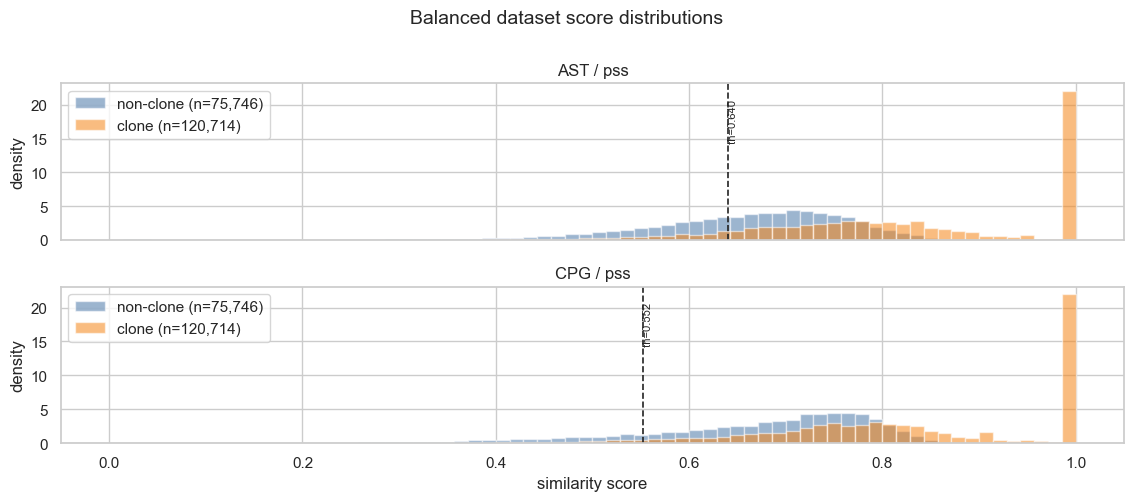

In [5]:
if scores_df.empty:
    print("No pair-score CSV found.")
else:
    bins = np.linspace(0, 1, 71)
    for metric_name in sorted(scores_df["metric"].astype(str).unique()):
        metric_scores = scores_df[scores_df["metric"].astype(str).eq(metric_name)].copy()
        graph_types = list(results_df[results_df["metric"].astype(str).eq(metric_name)]["graph_type"].astype(str))
        fig, axes = plt.subplots(len(graph_types), 1, figsize=(11.5, max(3.2, 2.5 * len(graph_types))), sharex=True, squeeze=False)
        for ax, graph_type in zip(axes.flat, graph_types):
            sub = metric_scores[metric_scores["graph_type"].astype(str).eq(graph_type)].copy()
            threshold_row = results_df[(results_df["graph_type"].astype(str).eq(graph_type)) & (results_df["metric"].astype(str).eq(metric_name))]
            threshold = float(threshold_row.iloc[0]["best_threshold"]) if not threshold_row.empty else np.nan
            for label, color, text in [(0, "#4C78A8", "non-clone"), (1, "#F58518", "clone")]:
                values = sub.loc[sub["label"].astype(int).eq(label), "score"].astype(float).clip(0, 1)
                ax.hist(values, bins=bins, density=True, alpha=0.55, color=color, label=f"{text} (n={len(values):,})")
            if pd.notna(threshold):
                ax.axvline(threshold, color="#222", linestyle="--", linewidth=1.2)
                ax.text(threshold, ax.get_ylim()[1] * 0.9, f" th={threshold:.3f}", rotation=90, va="top", fontsize=8)
            ax.set_title(f"{graph_type.upper()} / {metric_name}")
            ax.set_ylabel("density")
            ax.legend(loc="upper left")
        axes[-1][0].set_xlabel("similarity score")
        fig.suptitle("Balanced dataset score distributions", y=1.0, fontsize=14)
        fig.tight_layout()
        plt.show()
